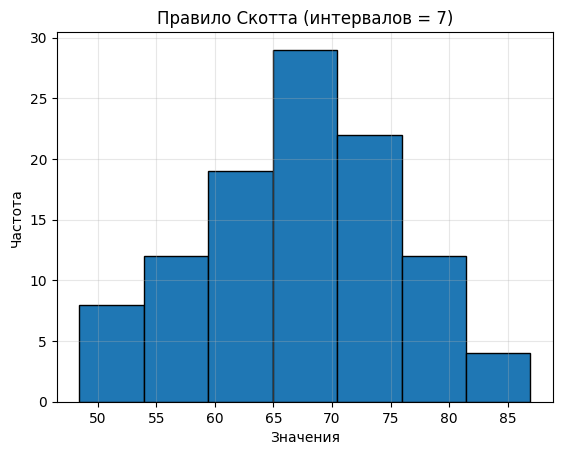

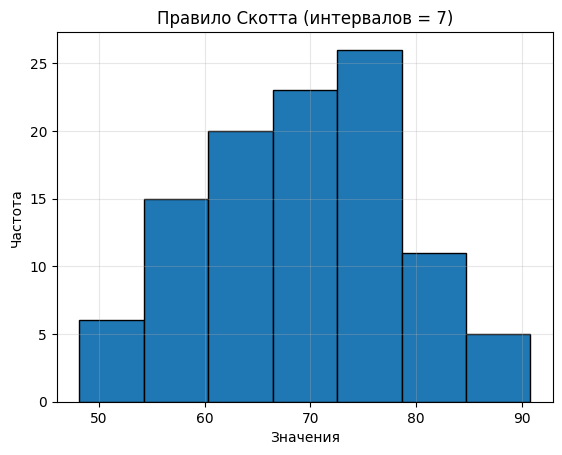

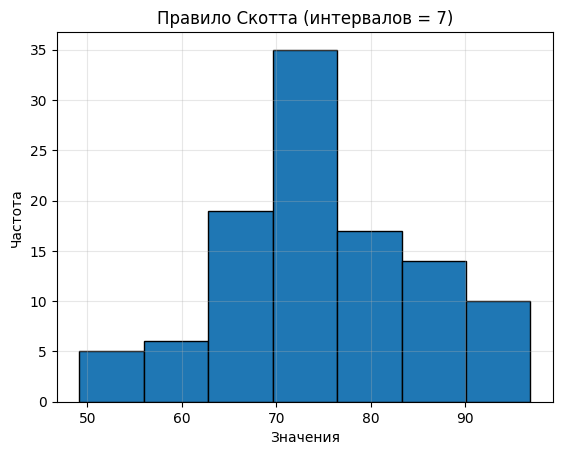

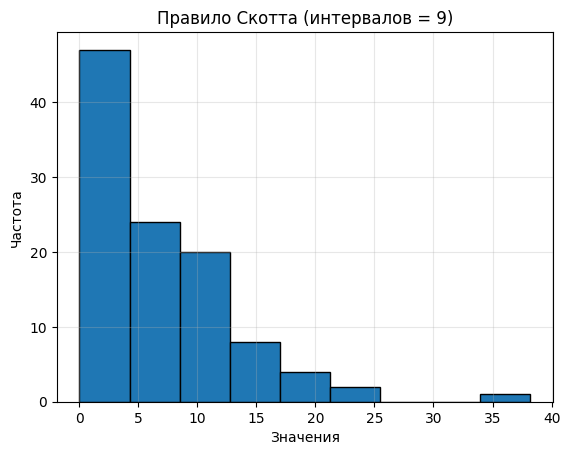

n = 106, alpha = 0.05
------------------------------
4.2. Сравнение средних X1 и X2:
t_obs = -1.543548306492761
p-value = 0.12420336592702015

4.3. Проверка mu = 75.24 для X3:
t_obs = -0.5023617731245462
p-value = 0.6164650051557109

4.4. Критерий Манна-Уитни для X1 и X2:
U_obs = 4982.5
p-value = 0.15505433778921868

4.5. Критерий Пирсона для X4 (Exp):
chi2_obs = 8.442915002915992
p-value = 0.2951613649313582


In [ ]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def hist_scott(n,data,std_unbiased):

    #ширина интервала
    h = 3.5 * std_unbiased * n**(-1/3)

    #число интервалов
    k = int((max(data) - min(data)) / h) + 1

    plt.hist(data, bins=k, edgecolor='black')
    plt.xlabel('Значения')
    plt.ylabel('Частота')
    plt.title(f'Правило Скотта (интервалов = {k})')
    plt.grid(True, alpha=0.3)
    plt.show()

    return k

def calculate_stats(n,data_sorted):

    #выборочное среднее
    vub_avg = sum(data_sorted) / n

    #дисперсии
    #смещенная (делим на n)
    var_biased = sum((x - vub_avg)**2 for x in data_sorted) / n

    #несмещенная (делим на n-1)
    var_unbiased = sum((x - vub_avg)**2 for x in data_sorted) / (n - 1)

    #стандартные отклонения
    std_biased = var_biased ** 0.5
    std_unbiased = var_unbiased ** 0.5

    hist_scott(n,data_sorted,std_unbiased)


X1,X2,X3,X4 = [],[],[],[]

with open('RGR2_A-5_X1-X4.csv', 'r') as file:
    reader = csv.reader((file))
    next(reader)
    for row in file:
        temp = row.split(";")
        if (temp[0]=="X1"):
            break
        X1.append(float(temp[0]))
        X2.append(float(temp[1]))
        X3.append(float(temp[2]))
        X4.append(float(temp[3]))

calculate_stats(106, sorted(X1))
calculate_stats(106, sorted(X2))
calculate_stats(106, sorted(X3))
calculate_stats(106, sorted(X4))


alpha = 0.05
n = len(X1)

print(f"n = {n}, alpha = {alpha}")
print("-" * 30)

# Проверка равенства средних (t-критерий Стьюдента)
t_stat, p_val2 = stats.ttest_ind(X1, X2)
print("4.2. Сравнение средних X1 и X2:")
print(f"t_obs = {t_stat}")
print(f"p-value = {p_val2}")

# Гипотеза о параметре (X3)
mu0 = 75.24
t_stat3, p_val3 = stats.ttest_1samp(X3, mu0)
print("\n4.3. Проверка mu = 75.24 для X3:")
print(f"t_obs = {t_stat3}")
print(f"p-value = {p_val3}")

# Непараметрический критерий (X1 и X2)
u_stat, p_val4 = stats.mannwhitneyu(X1, X2)
print("\n4.4. Критерий Манна-Уитни для X1 и X2:")
print(f"U_obs = {u_stat}")
print(f"p-value = {p_val4}")

# Критерий согласия Пирсона (X4)
lam = 0.106
counts, bins = np.histogram(X4, bins=8)

# Считаем теоретические вероятности p_i = exp(-lambda * left) - exp(-lambda * right)
probs = np.exp(-lam * bins[:-1]) - np.exp(-lam * bins[1:])
# Сумма вероятностей должна быть 1, корректируем последний интервал
probs /= probs.sum()
expected = probs * n

chi_stat, p_val5 = stats.chisquare(f_obs=counts, f_exp=expected)
print("\n4.5. Критерий Пирсона для X4 (Exp):")
print(f"chi2_obs = {chi_stat}")
print(f"p-value = {p_val5}")

